Cell 1 – Cài thư viện

In [ ]:
!pip install tensorflow numpy pandas scikit-learn


Cell 2 – Import tất cả thư viện

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


Cell 3 – Load database từ Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

csv_path = "/content/drive/MyDrive/dataset_voice_control_v2.csv"

df = pd.read_csv(csv_path)
df.head()

,label,context
0,clickchuotphai,Làm ơn chạm chuột phải
1,clickchuotphai,Hãy giúp tôi click phải
2,clickchuotphai,vui lòng kích chuột phải
3,clickchuotphai,Tôi cần bạn bấm nhẹ chuột phải
4,clickchuotphai,Vui lòng cho mình chuột phải một cái


Cell 4 – Tiền xử lý dữ liệu

In [4]:
texts = df["context"].astype(str).tolist()
labels = df["label"].astype(str).tolist()

# Encode label → số
label_encoder = LabelEncoder()
labels_num = label_encoder.fit_transform(labels)
labels_cat = to_categorical(labels_num)

# Tokenizer
MAX_WORDS = 5000
MAX_LEN = 20

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN)

y = labels_cat


Cell 5 – Tách train / test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Cell 6 – Xây dựng mô hình LSTM

In [6]:
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,467 (1.36 MB)

 Trainable params: 355,467 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Cell 7 – Train mô hình

In [7]:
early = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.1703 - loss: 2.3756 - val_accuracy: 0.1979 - val_loss: 2.2504
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2043 - loss: 2.2012 - val_accuracy: 0.3177 - val_loss: 1.8921
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3640 - loss: 1.8686 - val_accuracy: 0.6146 - val_loss: 1.4400
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5512 - loss: 1.3498 - val_accuracy: 0.8698 - val_loss: 0.7588
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8379 - loss: 0.6598 - val_accuracy: 0.9375 - val_loss: 0.3238
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9162 - loss: 0.3598 - val_accuracy: 0.9635 - val_loss: 0.1996
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9832 - loss: 0.1806 - val_accuracy: 0.9896 - val_loss: 0.0980
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9965 - loss: 0.0934 - val_accuracy: 0.9948 - v

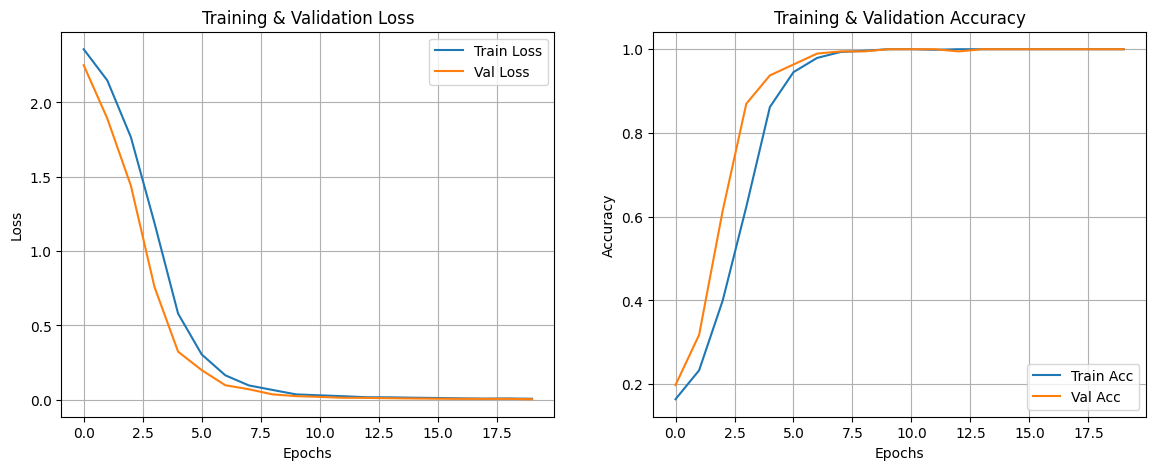

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0036
Test accuracy: 1.0
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification report:
                 precision    recall  f1-score   support

 clickchuotphai       1.00      1.00      1.00        18
 clickchuottrai       1.00      1.00      1.00        21
dungchuongtrinh       1.00      1.00      1.00        23
          moapp       1.00      1.00      1.00        25
     nhapvanban       1.00      1.00      1.00        35
        phongto       1.00      1.00      1.00        18
         thunho       1.00      1.00      1.00        17
        vuotlen       1.00      1.00      1.00        21
       vuotphai       1.00      1.00      1.00        17
       vuottrai       1.00      1.00      1.00        22
      vuotxuong       1.00      1.00      1.00        23

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get class names from label_encoder
label_classes = label_encoder.classes_

# ==========================
# 2. Vẽ biểu đồ Loss & Accuracy
# ==========================
plt.figure(figsize=(14, 5))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# --- ACCURACY ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.show()

# ==========================
# 3. Evaluate trên test set
# ==========================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("Test accuracy:", test_acc)

# ==========================
# 4. Classification Report
# ==========================
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# Get unique labels present in the test set and filter target_names accordingly
unique_labels_in_test = np.unique(y_true)
filtered_target_names = label_classes[unique_labels_in_test]

print("\nClassification report:")
print(classification_report(y_true, y_pred_classes, target_names=filtered_target_names, labels=unique_labels_in_test))


Cell 8 – Lưu mô hình & tokenizer

In [12]:
model.save("/content/voice_action_model.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Đã lưu mô hình và tokenizer!")

Đã lưu mô hình và tokenizer!


In [16]:
# ===== TEST MÔ HÌNH SAU KHI TRAIN =====

import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# === Load lại model đã train ===
model = load_model("voice_action_model.h5")
#tokenizer = pickle.load(open("tokenizer_1.pkl", "rb"))
#label_encoder = pickle.load(open("label_encoder_1.pkl", "rb"))

MAX_LEN = 20

def predict_action_from_text(input_text):
    # Chuyển văn bản sang sequence số
    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    # Dự đoán
    pred = model.predict(padded)[0]

    # Lấy lớp dự đoán có xác suất cao nhất
    class_id = np.argmax(pred)
    action = label_encoder.classes_[class_id]

    # Xác suất tự tin (confidence)
    confidence = float(pred[class_id]) * 100

    print("=====================================")
    print(" Văn bản nhập:", input_text)
    print(" Hành động dự đoán:", action)
    print(f" Độ tự tin: {confidence:.2f}%")
    print(" Xác suất từng lớp:")
    for cls, p in zip(label_encoder.classes_, pred):
        print(f"   - {cls}: {p*100:.2f}%")

    return action


# ==== CHẠY TEST ==== #
text = input("Nhập văn bản để kiểm tra mô hình: ")

predict_action_from_text(text)


Nhập văn bản để kiểm tra mô hình: hãy viết Việt Nam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
 Văn bản nhập: hãy viết Việt Nam
 Hành động dự đoán: vuotlen
 Độ tự tin: 37.51%
 Xác suất từng lớp:
   - clickchuotphai: 0.08%
   - clickchuottrai: 2.62%
   - dungchuongtrinh: 2.99%
   - moapp: 2.37%
   - nhapvanban: 29.05%
   - phongto: 2.92%
   - thunho: 0.01%
   - vuotlen: 37.51%
   - vuotphai: 0.01%
   - vuottrai: 0.13%
   - vuotxuong: 22.31%


np.str_('vuotlen')